# 2026-02-04 Nonlinear solvers

## Last time

* Cost of linear solvers
* Sparse matrix representation
* Assembling sparse matrices

## Today

* Discuss portfolio
* Newton's method for systems
* Bratu nonlinear PDE
* p-Laplacian
* Techniques for differentiation

In [14]:
using Plots
default(linewidth=3)
using LinearAlgebra
using SparseArrays

function vander(x, k=nothing)
    if k === nothing
        k = length(x)
    end
    V = ones(length(x), k)
    for j = 2:k
        V[:, j] = V[:, j-1] .* x
    end
    V
end

function fdstencil(source, target, k)
    "kth derivative stencil from source to target"
    x = source .- target
    V = vander(x)
    rhs = zero(x)'
    rhs[k+1] = factorial(k)
    rhs / V
end

function my_spy(A)
    cmax = norm(vec(A), Inf)
    s = max(1, ceil(120 / size(A, 1)))
    spy(A, marker=(:square, s), c=:diverging_rainbow_bgymr_45_85_c67_n256, clims=(-cmax, cmax))
end


function advdiff_sparse(n, kappa, wind, forcing)
    x = LinRange(-1, 1, n)
    xstag = (x[1:end-1] + x[2:end]) / 2
    rhs = forcing.(x)
    kappa_stag = kappa.(xstag)
    rows = [1, n]
    cols = [1, n]
    vals = [1., 1.] # diagonals entries (float)
    rhs[[1,n]] .= 0 # boundary condition
    for i in 2:n-1
        flux_L = -kappa_stag[i-1] * fdstencil(x[i-1:i], xstag[i-1], 1) +
            wind * (wind > 0 ? [1 0] : [0 1])
        flux_R = -kappa_stag[i] * fdstencil(x[i:i+1], xstag[i], 1) +
            wind * (wind > 0 ? [1 0] : [0 1])
        weights = fdstencil(xstag[i-1:i], x[i], 1)
        append!(rows, [i,i,i])
        append!(cols, i-1:i+1)
        append!(vals, weights[1] *  [flux_L..., 0] + weights[2] * [0, flux_R...])
    end
    L = sparse(rows, cols, vals)
    x, L, rhs
end

advdiff_sparse (generic function with 1 method)

# Assembly cost

minimum(diff(x)) = 0.005012531328320691


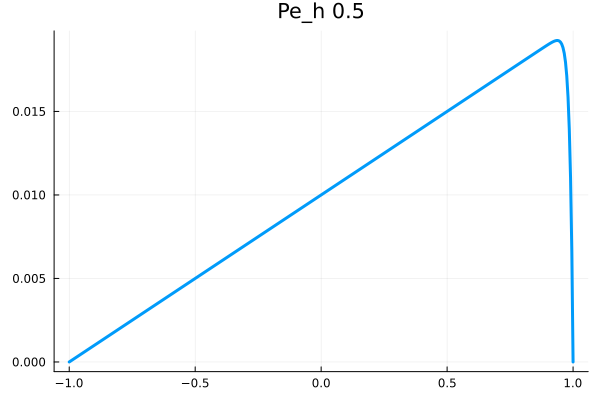

In [15]:
n = 400; h = 2/n
kappa = 1
wind = 100
x, L, rhs = advdiff_sparse(n, x -> kappa, wind, one)
@show minimum(diff(x))
plot(x, L \ rhs, legend=:none, title="Pe_h $(wind*h/kappa)")

In [16]:
n = 10000
@time advdiff_sparse(n, one, 1, one);

  0.085256 seconds (938.93 k allocations: 37.323 MiB, 66.11% gc time)


In [17]:
# It's also possible to dynamically insert.
# (But performance this way is generally poor.)
A = spzeros(5, 5)
A[1,1] = 3
A

5×5 SparseMatrixCSC{Float64, Int64} with 1 stored entry:
 3.0   ⋅    ⋅    ⋅    ⋅ 
  ⋅    ⋅    ⋅    ⋅    ⋅ 
  ⋅    ⋅    ⋅    ⋅    ⋅ 
  ⋅    ⋅    ⋅    ⋅    ⋅ 
  ⋅    ⋅    ⋅    ⋅    ⋅ 

## Newton-Raphson Method

Much of numerical analysis reduces to [Taylor series](https://en.wikipedia.org/wiki/Taylor_series), the approximation
$$ f(x) = f(x_0) + f'(x_0) (x-x_0) + f''(x_0) (x - x_0)^2 / 2 + \underbrace{\dotsb}_{O((x-x_0)^3)} $$
centered on some reference point $x_0$.

In numerical computation, it is exceedingly rare to look beyond the first-order approximation
$$ \tilde f_{x_0}(x) = f(x_0) + f'(x_0)(x - x_0) . $$
Since $\tilde f_{x_0}(x)$ is a linear function, we can explicitly compute the unique solution of $\tilde f_{x_0}(x) = 0$ as
$$ x = x_0 - f(x_0) / f'(x_0) . $$
This is Newton's Method (aka Newton-Raphson or Newton-Raphson-Simpson) for finding the roots of differentiable functions.

# An implementation

In [48]:
function newton(f, fp, x0; tol=1e-8, verbose=false)
    x = x0
    for k in 1:100 # max number of iterations
        fx = f(x)
        fpx = fp(x)
        if verbose
            println("[$k] x=$x  f(x)=$fx  f'(x)=$fpx")
        end
        if abs(fx) < tol
            return x, fx, k
        end
        x = x - fx / fpx
    end  
end
eps = 1
newton(x -> eps*(cos(x) - x), x -> eps*(-sin(x) - 1), 1; tol=1e-15, verbose=true)

[1] x=1  f(x)=-0.45969769413186023  f'(x)=-1.8414709848078965
[2] x=0.7503638678402439  f(x)=-0.018923073822117442  f'(x)=-1.6819049529414878
[3] x=0.7391128909113617  f(x)=-4.6455898990771516e-5  f'(x)=-1.6736325442243012
[4] x=0.739085133385284  f(x)=-2.847205804457076e-10  f'(x)=-1.6736120293089505
[5] x=0.7390851332151607  f(x)=0.0  f'(x)=-1.6736120291832148


(0.7390851332151607, 0.0, 5)

# That's really fast!

* 10 digits of accuracy in 4 iterations.
* How can this break down?

$$ x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)} $$

In [55]:
newton(x -> cos(x) - x, x -> -sin(x) - 1, 3pi/2 + 0.1; verbose=true)

[1] x=4.812388980384689  f(x)=-4.712555563737862  f'(x)=-0.0049958347219741794
[2] x=-938.4845425633443  f(x)=937.8258080987292  f'(x)=-0.24762449194016167
[3] x=2848.805643277216  f(x)=-2849.6201641342545  f'(x)=-1.5801342719142093
[4] x=1045.4018346362186  f(x)=-1046.134532203049  f'(x)=-1.6805543883928888
[5] x=422.90812694761144  f(x)=-423.2640625450803  f'(x)=-1.9345104870756957
[6] x=204.11165860439363  f(x)=-205.10744208477567  f'(x)=-1.091734727329395
[7] x=16.238691893414142  f(x)=-17.1011303904656  f'(x)=-0.4938381298402409
[8] x=-18.390327935406894  f(x)=19.28672289996763  f'(x)=-1.4432562097818384
[9] x=-5.026988308492699  f(x)=5.3364237974778055  f'(x)=-1.9509204373429716
[10] x=-2.2916518512327237  f(x)=1.631624232475013  f'(x)=-0.24875866562267357
[11] x=4.267413049645629  f(x)=-4.69784920465022  f'(x)=-0.09737897406227891
[12] x=-43.97553929082267  f(x)=44.9755164565775  f'(x)=-1.0067578079974873
[13] x=0.6980814144758583  f(x)=0.06799535109918953  f'(x)=-1.642749087316

(0.7390851332151609, -4.440892098500626e-16, 16)

# Convergence of fixed-point iteration

Consider the iteration
$$x_{k+1} = g(x_k)$$
where $g$ is a continuously differentiable function.
Suppose that there exists a fixed point $x_* = g(x_*)$.  By the [mean value theorem](https://en.wikipedia.org/wiki/Mean_value_theorem), we have that
$$ x_{k+1} - x_* = g(x_k) - g(x_*) = g'(c_k) (x_k - x_*) $$
for some $c_i$ between $x_k$ and $x_*$.

Taking absolute values, $$|e_{k+1}| = |g'(c_k)| |e_k|,$$ which converges to zero if $|g'(c_k)| < 1$.

## Exercise

* Write Newton's method for $f(x) = 0$ from initial guess $x_0$ as a fixed point method.
* Suppose the Newton iterates $x_k$ converge to a simple root $x_*$, $x_k \to x_*$. What is $\lvert g'(x_*) \rvert$ for Newton's method?

# Newton for systems of equations

Let $\mathbf u \in \mathbb R^n$ and consider the function $\mathbf f(\mathbf u) \in \mathbb R^n$. Then
$$ \mathbf f(\mathbf u) = \mathbf f(\mathbf u_0) + \underbrace{\mathbf f'(\mathbf u_0)}_{n\times n} \underbrace{\mathbf \delta \mathbf u}_{n\times 1} + \frac 1 2 \underbrace{\mathbf f''(\mathbf u_0)}_{n\times n \times n} {(\delta \mathbf u)^2}_{n\times n} + O(|\delta\mathbf u|^3).$$

We drop all but the first two terms and name the Jacobian matrix $J(\mathbf u) = \mathbf f'(\mathbf u)$,
$$ \mathbf f(\mathbf u) \approx \mathbf f(\mathbf u_0) + J \delta \mathbf u .$$
Solving the right hand side equal to zero yields
\begin{align}
J \delta \mathbf u &= -\mathbf f(\mathbf u_k) \\
\mathbf u_{k+1} &= \mathbf u_k + \delta \mathbf u
\end{align}

# Newton in code


In [20]:
function newton(residual, jacobian, u0; maxits=20)
    u = u0
    uhist = [copy(u)]
    normhist = []
    for k in 1:maxits
        f = residual(u)
        push!(normhist, norm(f))
        J = jacobian(u)
        delta_u = - J \ f
        u += delta_u
        push!(uhist, copy(u))
    end
    uhist, normhist
end

newton (generic function with 1 method)

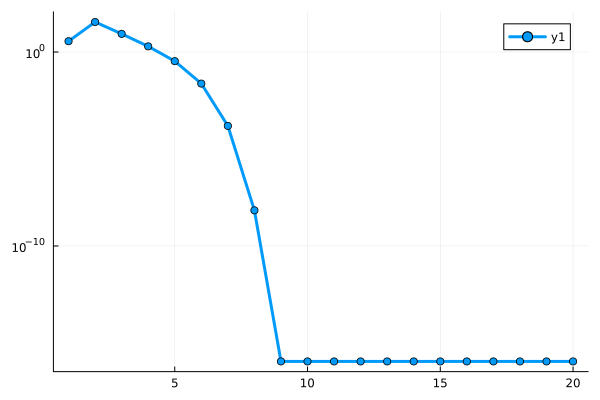

In [21]:
function residual(u)
    x, y = u
    [x^2 + y^2 - 1, x^2 - y]
end
function jacobian(u)
    x, y = u
    [2x 2y; 2x -1]
end

uhist, normhist = newton(residual, jacobian, [0.1, 2])
plot(normhist, marker=:circle, yscale=:log10)

# Plotting the trajectory

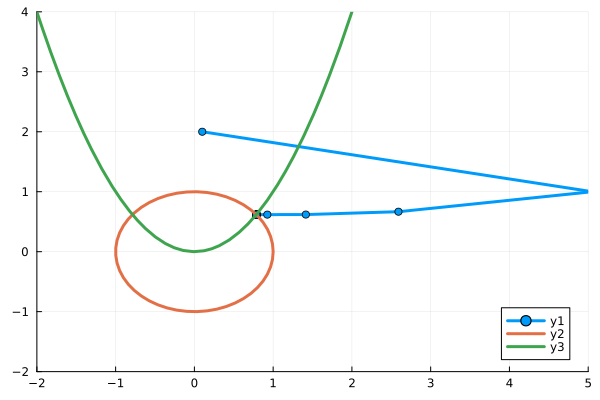

In [22]:
xy = hcat(uhist...)
plot(xy[1,:], xy[2,:], marker=:circle)
circle = exp.(1im*LinRange(0, 2*pi, 50))
plot!(real(circle), imag(circle))
plot!(x -> x^2, xlims=(-2, 5), ylims=(-2, 4), axes=:equal, legend=:bottomright)

# Bratu problem

$$-(u_x)_x - \lambda e^{u}= 0$$

In [23]:
function bratu_f(u; lambda=.5)
    n = length(u)
    h = 2 / (n - 1)
    weights = -fdstencil([-h, 0, h], 0, 2)
    u = copy(u)
    f = copy(u)
    u[1] = 0
    u[n] = 1
    f[n] -= 1
    for i in 2:n-1
        f[i] = weights * u[i-1:i+1] - lambda * exp(u[i])
    end
    f
end

bratu_f (generic function with 1 method)

In [24]:
function bratu_J(u; lambda=.5)
    n = length(u)
    h = 2 / (n - 1)
    weights = -fdstencil([-h, 0, h], 0, 2)
    rows = [1, n]
    cols = [1, n]
    vals = [1., 1.] # diagonals entries (float)
    for i in 2:n-1
        append!(rows, [i,i,i])
        append!(cols, i-1:i+1)
        append!(vals, weights + [0 -lambda*exp(u[i]) 0])
    end
    sparse(rows, cols, vals)
end

bratu_J (generic function with 1 method)

# Solving Bratu

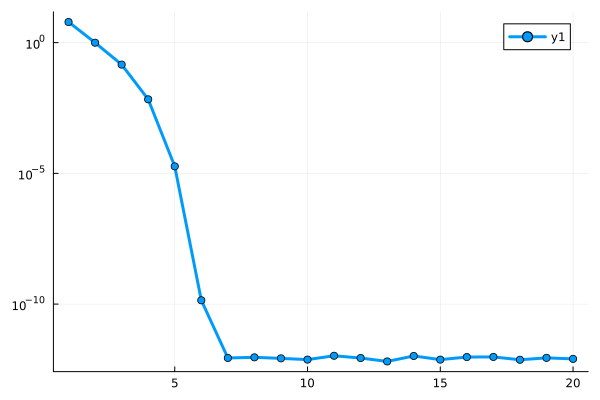

In [25]:
n = 50
x = collect(LinRange(-1., 1, n))
u0 = (1 .+ x) ./ 2
uhist, normhist = newton(bratu_f, bratu_J, u0);

plot(normhist, marker=:circle, yscale=:log10)

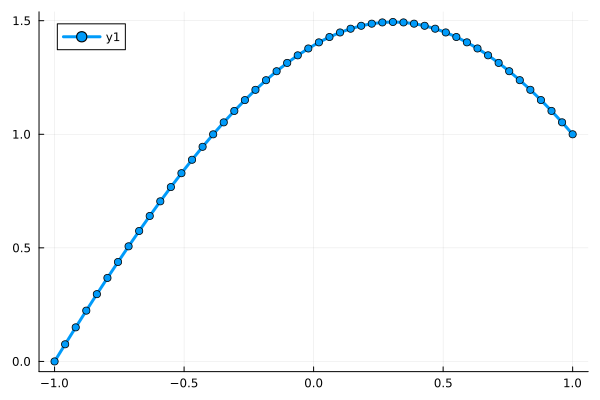

In [26]:
plot(x, uhist[end], marker=:circle)

# $p$-Laplacian

$$ -(|u_x|^{p-2} u_x)_x = 0 $$

In [27]:
plaplace_p = 1.5
plaplace_forcing = 0.
function plaplace_f(u)
    n = length(u)
    h = 2 / (n - 1)
    u = copy(u)
    f = copy(u)
    u[[1, n]] = [0, 1]
    f[n] -= 1
    for i in 2:n-1
        u_xstag = diff(u[i-1:i+1]) / h
        kappa_stag = abs.(u_xstag) .^ (plaplace_p - 2)
        f[i] = [1/h, -1/h]' *
            (kappa_stag .* u_xstag) - plaplace_forcing
    end
    f
end

plaplace_f (generic function with 1 method)

In [28]:
function plaplace_J(u)
    n = length(u)
    h = 2 / (n - 1)
    u = copy(u)
    u[[1, n]] = [0, 1]
    rows = [1, n]
    cols = [1, n]
    vals = [1., 1.] # diagonals entries (float)
    for i in 2:n-1
        js = i-1:i+1
        u_xstag = diff(u[js]) / h
        kappa_stag = abs.(u_xstag) .^ (plaplace_p - 2)
        fi = [h, -h]' * (kappa_stag .* u_xstag)
        fi_ujs = [-kappa_stag[1]/h^2,
                  sum(kappa_stag)/h^2,
                  -kappa_stag[2]/h^2]
        mask = 1 .< js .< n
        append!(rows, [i,i,i][mask])
        append!(cols, js[mask])
        append!(vals, fi_ujs[mask])
    end
    sparse(rows, cols, vals)
end

plaplace_J (generic function with 1 method)

# Try solving

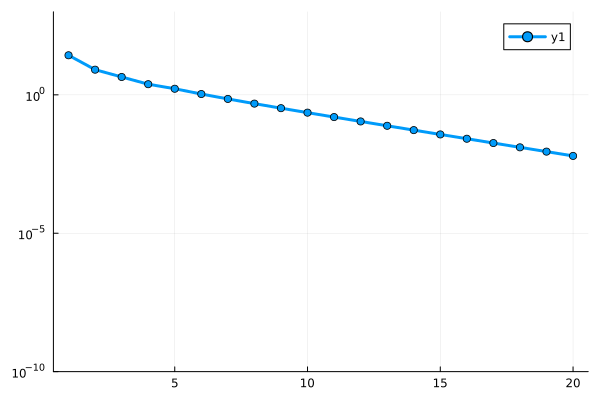

In [29]:
n = 20
x = collect(LinRange(-1., 1, n))
u0 = (1 .+ x)

plaplace_p = 1.3 # try different values
plaplace_forcing = 1
uhist, normhist = newton(plaplace_f, plaplace_J, u0; maxits=20);
plot(normhist, marker=:circle, yscale=:log10, ylims=(1e-10, 1e3))

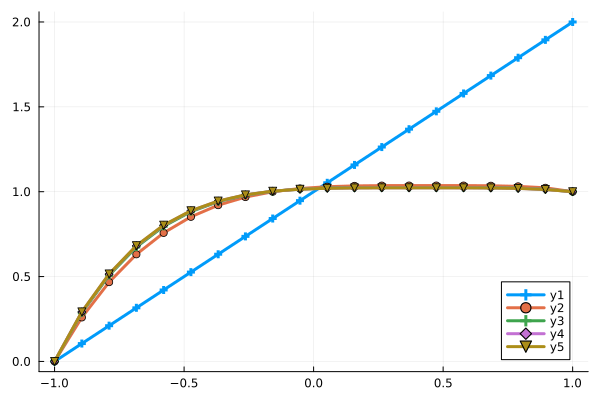

In [30]:
plot(x, uhist[1:5:end], marker=:auto, legend=:bottomright)